# 02. churn_any baseline 분석

In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier

RANDOM_STATE = 42


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 여부",
    "a03026_tminus1": "데이터 무제한 여부",
    "c01002_tminus1": "월평균 휴대폰 이용금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 소득 구간",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: rename_feature_label(x))

def prettify_transformed_feature_name(name):
    if "__" in name:
        name = name.split("__", 1)[1]

    matched_base = None
    for base_name in FEATURE_LABEL_MAP:
        if name == base_name or name.startswith(f"{base_name}_"):
            matched_base = base_name
            break

    if matched_base is None:
        return name

    base_label = rename_feature_label(matched_base)
    suffix = name[len(matched_base):].lstrip("_")
    return base_label if not suffix else f"{base_label}={suffix}"


In [4]:
# ============================================================
# 3. 컬럼 구성 확인
# ============================================================
# 예측에 쓰지 않을 컬럼
# - pid: 그룹 분리용
# - year_t0, year_t1: 식별/시점 정보
# - telco_t0, telco_t1: 라벨 생성에 직접 연결될 수 있어 baseline에서는 제외
# - churn_to_mvno: 다른 타깃
# - churn_any: 현재 타깃

target_col = "churn_any"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

# 데이터 정의서 기준으로 변수 역할을 구분
nominal_features = ["a03002_tminus1", "c02001_tminus1"]
binary_features = ["a03024_tminus1", "a03026_tminus1", "c02003_tminus1", "job1_tminus1"]
ordinal_features = ["income1_tminus1"]
numeric_features = ["c01002_tminus1", "c01004_tminus1", "age1_tminus1"]

modeled_feature_cols = nominal_features + binary_features + ordinal_features + numeric_features
missing_feature_defs = sorted(set(modeled_feature_cols) - set(feature_cols))
if missing_feature_defs:
    raise ValueError(f"정의한 feature가 데이터에 없습니다: {missing_feature_defs}")

print("사용할 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("명목형 변수:", nominal_features)
print("이진 변수:", binary_features)
print("순서형 변수:", ordinal_features)
print("수치형 변수:", numeric_features)


사용할 feature 개수: 10
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']
명목형 변수: ['a03002_tminus1', 'c02001_tminus1']
이진 변수: ['a03024_tminus1', 'a03026_tminus1', 'c02003_tminus1', 'job1_tminus1']
순서형 변수: ['income1_tminus1']
수치형 변수: ['c01002_tminus1', 'c01004_tminus1', 'age1_tminus1']


In [5]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("y mean:", y.mean())
print("고유 pid 수:", groups.nunique())


X shape: (41299, 10)
y mean: 0.36276907431172667
고유 pid 수: 10071


In [6]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

cv = GroupKFold(n_splits=5)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate :", y_test.mean())
print("Train pid 수:", groups_train.nunique())
print("Test pid 수 :", groups_test.nunique())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))


Train shape: (32992, 10)
Test shape : (8307, 10)
Train churn rate: 0.36520974781765275
Test churn rate : 0.3530757192729024
Train pid 수: 8056
Test pid 수 : 2015
겹치는 pid 수: 0


In [7]:
# ============================================================
# 6. 범주형 처리 / 고정 threshold 함수
# ============================================================
def build_preprocessor(scale_numeric=False):
    ordinal_steps = [("imputer", SimpleImputer(strategy="most_frequent"))]
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        ordinal_steps.append(("scaler", StandardScaler()))
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
                ]),
                nominal_features + binary_features
            ),
            (
                "ord",
                Pipeline(ordinal_steps),
                ordinal_features
            ),
            (
                "num",
                Pipeline(numeric_steps),
                numeric_features
            )
        ],
        remainder="drop"
    )

FIXED_THRESHOLD = 0.5

def make_prediction_bundle(search, X_eval, threshold):
    best_estimator = search.best_estimator_
    y_proba = best_estimator.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return best_estimator, y_pred, y_proba


In [8]:
# ============================================================
# 7. Logistic Regression 파이프라인
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]


In [9]:
# ============================================================
# 8. Tree / Boosting 계열 모델 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [10]:
# ============================================================
# 9. 평가 함수 및 모델 성능 비교
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")
result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])

# baseline 비교에서는 실제 양성 탐지 성능을 우선 보기 위해
# F1 -> Recall -> PR-AUC 순으로 정렬한다.
result_df = result_df.sort_values(["f1", "recall", "pr_auc"], ascending=False).reset_index(drop=True)
display(result_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,DecisionTree,0.450825,0.378451,0.864644,0.526469,0.552298,0.380511
1,LogisticRegression,0.524257,0.381429,0.558814,0.453389,0.547991,0.383012
2,RandomForest,0.573853,0.411231,0.479373,0.442695,0.576183,0.409014
3,XGBoost,0.645961,0.469697,0.021139,0.040457,0.594160,0.423095
4,GradientBoosting,0.645119,0.397260,0.009887,0.019295,0.589186,0.414832


In [11]:
# ============================================================
# 10. 상세 리포트 출력
# ============================================================
# 현재 y_pred_*는 각 모델의 predict() 결과이므로,
# threshold 튜닝 결과가 아니라 default threshold 기준 상세 리포트이다.
model_reports = [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb),
    ("XGBoost", y_pred_xgb)
]

for model_name, y_pred in model_reports:
    print(f"===== {model_name} | default threshold =====")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print()


===== Logistic Regression | default threshold =====
              precision    recall  f1-score   support

           0     0.6773    0.5054    0.5789      5374
           1     0.3814    0.5588    0.4534      2933

    accuracy                         0.5243      8307
   macro avg     0.5294    0.5321    0.5161      8307
weighted avg     0.5728    0.5243    0.5346      8307

Confusion Matrix
[[2716 2658]
 [1294 1639]]

===== Decision Tree | default threshold =====
              precision    recall  f1-score   support

           0     0.7528    0.2250    0.3464      5374
           1     0.3785    0.8646    0.5265      2933

    accuracy                         0.4508      8307
   macro avg     0.5656    0.5448    0.4364      8307
weighted avg     0.6206    0.4508    0.4100      8307

Confusion Matrix
[[1209 4165]
 [ 397 2536]]

===== Random Forest | default threshold =====
              precision    recall  f1-score   support

           0     0.6876    0.6254    0.6550      5374
   

In [12]:
# ============================================================
# 11. Logistic Regression 계수 해석
# ============================================================
log_model = logistic_pipe.named_steps["model"]
log_feature_names = X_train.columns

coef_df = pd.DataFrame({
    "feature": log_feature_names,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = coef_df["feature"].map(prettify_transformed_feature_name)
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))


,변수,계수,절대값
8,개인 소득 구간,-0.127792,0.127792
7,나이,0.095973,0.095973
0,스마트폰 구분,0.093428,0.093428
9,직업 유무,0.090939,0.090939
2,데이터 무제한 여부,-0.056129,0.056129
3,월평균 휴대폰 이용금액,0.055260,0.055260
4,월평균 기기 할부금,-0.046503,0.046503
5,결합상품 가입 여부,-0.031298,0.031298
6,휴대폰 요금 부담자,-0.031049,0.031049
1,음성 무제한 여부,-0.008210,0.008210


In [13]:
# ============================================================
# 12. Random Forest 오분류 분석
# ============================================================
error_df_rf = X_test.copy()
error_df_rf["y_true"] = y_test.values
error_df_rf["y_pred_rf"] = y_pred_rf
error_df_rf["y_proba_rf"] = y_proba_rf

fp_df_rf = error_df_rf[(error_df_rf["y_true"] == 0) & (error_df_rf["y_pred_rf"] == 1)]
fn_df_rf = error_df_rf[(error_df_rf["y_true"] == 1) & (error_df_rf["y_pred_rf"] == 0)]

print("False Positive 개수:", len(fp_df_rf))
print("False Negative 개수:", len(fn_df_rf))

# 수치형/순서형 변수는 평균 비교
numeric_like_cols = numeric_features + ordinal_features
summary_rows_rf_num = []
for col in numeric_like_cols:
    summary_rows_rf_num.append({
        "변수": rename_feature_label(col),
        "전체 평균": error_df_rf[col].mean(),
        "RF FP 평균": fp_df_rf[col].mean() if len(fp_df_rf) > 0 else np.nan,
        "RF FN 평균": fn_df_rf[col].mean() if len(fn_df_rf) > 0 else np.nan
    })

error_summary_rf_num_df = pd.DataFrame(summary_rows_rf_num)
display(error_summary_rf_num_df)

# 범주형/이진 변수는 최빈값과 비율 비교
categorical_like_cols = nominal_features + binary_features
summary_rows_rf_cat = []
for col in categorical_like_cols:
    total_mode = error_df_rf[col].mode(dropna=True)
    fp_mode = fp_df_rf[col].mode(dropna=True)
    fn_mode = fn_df_rf[col].mode(dropna=True)

    total_top = total_mode.iloc[0] if not total_mode.empty else np.nan
    fp_top = fp_mode.iloc[0] if not fp_mode.empty else np.nan
    fn_top = fn_mode.iloc[0] if not fn_mode.empty else np.nan

    summary_rows_rf_cat.append({
        "변수": rename_feature_label(col),
        "전체 최빈값": total_top,
        "전체 최빈 비율": (error_df_rf[col] == total_top).mean() if pd.notna(total_top) else np.nan,
        "RF FP 최빈값": fp_top,
        "RF FP 최빈 비율": (fp_df_rf[col] == fp_top).mean() if pd.notna(fp_top) and len(fp_df_rf) > 0 else np.nan,
        "RF FN 최빈값": fn_top,
        "RF FN 최빈 비율": (fn_df_rf[col] == fn_top).mean() if pd.notna(fn_top) and len(fn_df_rf) > 0 else np.nan
    })

error_summary_rf_cat_df = pd.DataFrame(summary_rows_rf_cat)
display(error_summary_rf_cat_df)


False Positive 개수: 2013
False Negative 개수: 1527


,변수,전체 평균,RF FP 평균,RF FN 평균
0,월평균 휴대폰 이용금액,5.223546,5.321411,5.160445
1,월평균 기기 할부금,1.613579,1.555390,1.621480
2,나이,48.163717,51.185792,47.648985
3,개인 소득 구간,4.930300,4.943865,4.844794


,변수,전체 최빈값,전체 최빈 비율,RF FP 최빈값,RF FP 최빈 비율,RF FN 최빈값,RF FN 최빈 비율
0,스마트폰 구분,3.0,0.478512,3.0,0.591654,3.0,0.440733
1,휴대폰 요금 부담자,1.0,0.682196,1.0,0.725782,1.0,0.674525
2,음성 무제한 여부,1.0,0.702179,1.0,0.705415,1.0,0.703340
3,데이터 무제한 여부,0.0,0.633442,0.0,0.665176,0.0,0.635887
4,결합상품 가입 여부,1.0,0.773685,1.0,0.756085,1.0,0.779306
5,직업 유무,1.0,0.608884,1.0,0.640338,1.0,0.592010


In [14]:
# ============================================================
# 13. Random Forest 중요도 해석
# ============================================================
rf_model = rf_pipe.named_steps["model"]
rf_feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = importance_df["feature"].map(prettify_transformed_feature_name)
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))


,변수,중요도
7,나이,0.409874
8,개인 소득 구간,0.168618
3,월평균 휴대폰 이용금액,0.153768
4,월평균 기기 할부금,0.077684
0,스마트폰 구분,0.051930
2,데이터 무제한 여부,0.032007
1,음성 무제한 여부,0.030040
5,결합상품 가입 여부,0.029442
6,휴대폰 요금 부담자,0.027477
9,직업 유무,0.019159


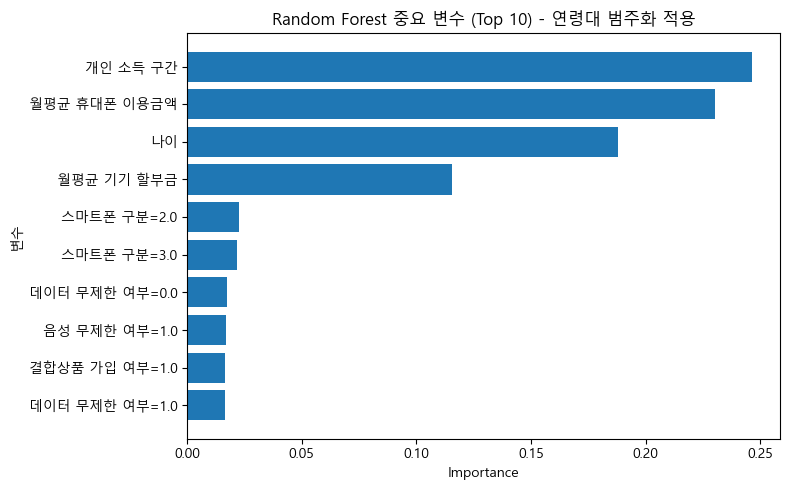

In [15]:
# ============================================================
# 13-1. 중요 변수 시각화
# ============================================================

X_train_binned = X_train.copy()
X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("preprocessor", build_preprocessor(scale_numeric=False)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]
rf_feature_names_binned = rf_pipe_binned.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": rf_feature_names_binned,
    "importance": rf_model_binned.feature_importances_
})

importance_df["feature_label"] = importance_df["feature"].map(prettify_transformed_feature_name)
importance_df = importance_df.sort_values("importance", ascending=False)

top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 적용")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 14. XGBoost 오분류 분석
# ============================================================
error_df_xgb = X_test.copy()
error_df_xgb["y_true"] = y_test.values
error_df_xgb["y_pred_xgb"] = y_pred_xgb
error_df_xgb["y_proba_xgb"] = y_proba_xgb

fp_df_xgb = error_df_xgb[(error_df_xgb["y_true"] == 0) & (error_df_xgb["y_pred_xgb"] == 1)]
fn_df_xgb = error_df_xgb[(error_df_xgb["y_true"] == 1) & (error_df_xgb["y_pred_xgb"] == 0)]

print("False Positive 개수:", len(fp_df_xgb))
print("False Negative 개수:", len(fn_df_xgb))

summary_rows_xgb = []
for col in feature_cols:
    summary_rows_xgb.append({
        "변수": rename_feature_label(col),
        "전체 평균": error_df_xgb[col].mean(),
        "XGB FP 평균": fp_df_xgb[col].mean() if len(fp_df_xgb) > 0 else np.nan,
        "XGB FN 평균": fn_df_xgb[col].mean() if len(fn_df_xgb) > 0 else np.nan
    })

error_summary_xgb_df = pd.DataFrame(summary_rows_xgb)
display(error_summary_xgb_df)


False Positive 개수: 70
False Negative 개수: 2871


,변수,전체 평균,XGB FP 평균,XGB FN 평균
0,스마트폰 구분,3.105092,2.914286,3.137583
1,음성 무제한 여부,0.702179,0.742857,0.708116
2,데이터 무제한 여부,0.366558,0.228571,0.359457
3,월평균 휴대폰 이용금액,5.223546,5.385714,5.264368
4,월평균 기기 할부금,1.613579,1.414286,1.600836
5,결합상품 가입 여부,0.773685,0.700000,0.754789
6,휴대폰 요금 부담자,1.947033,2.114286,1.904215
7,나이,48.163717,72.728571,48.912574
8,개인 소득 구간,4.930300,3.457143,4.866945
9,직업 유무,0.608884,0.528571,0.619993


In [17]:
# ============================================================
# 15. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]
xgb_feature_names = X_train.columns

xgb_importance_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = xgb_importance_df["feature"].map(prettify_transformed_feature_name)
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))


,변수,중요도
0,스마트폰 구분,0.153674
4,월평균 기기 할부금,0.121728
3,월평균 휴대폰 이용금액,0.110060
7,나이,0.097832
2,데이터 무제한 여부,0.096492
8,개인 소득 구간,0.095260
1,음성 무제한 여부,0.085854
5,결합상품 가입 여부,0.083267
9,직업 유무,0.078713
6,휴대폰 요금 부담자,0.077121


## [ 결과 해석 ]

### 1. `churn_any` hold-out baseline 해석

이 노트북의 결과는 `churn_any`에 대한 hold-out baseline 비교 결과다.
따라서 여기서의 수치는 `04_churn_any_cv_tuning.ipynb`의 GroupKFold 평균 결과와 직접 같은 선상에서 비교하면 안 되며,
현재 데이터 분할에서 baseline 모델들이 어떤 성향을 보였는지 확인하는 출발점으로 해석하는 것이 적절하다.

이번 hold-out baseline에서는 `DecisionTree`가 Recall `0.8646`, F1 `0.5265`로 가장 강한 탐지형 baseline 모습을 보였다.
실제 이탈자를 최대한 놓치지 않는 관점에서는 가장 적극적인 baseline으로 해석할 수 있다.
다만 Precision `0.3785`, Accuracy `0.4508`로 오탐이 많아 운영 부담은 큰 편이었다.

`RandomForest`는 Accuracy `0.5739`, Precision `0.4112`, Recall `0.4794`, F1 `0.4427`, PR-AUC `0.4090`을 기록하였다.
Recall과 F1은 `DecisionTree`보다 낮았지만, Accuracy와 Precision은 상대적으로 더 높게 나타났다.
즉 현재 hold-out split 기준에서는 이탈자를 아주 공격적으로 잡기보다는, 조금 더 보수적이고 균형적인 예측 패턴을 보인 baseline으로 해석할 수 있다.

`LogisticRegression`은 Recall `0.5588`, F1 `0.4534`를 기록하여
과도하게 보수적이지도, 지나치게 공격적이지도 않은 중간형 baseline 역할을 수행하였다.
해석 가능성이 높다는 점에서 기준선 모델로 활용할 의미가 있다.

반면 `GradientBoosting`과 `XGBoost`는 Accuracy는 각각 `0.6451`, `0.6460`으로 높게 나타났지만,
Recall은 각각 `0.0099`, `0.0211`에 그쳐 실제 churn 고객 탐지 관점에서는 실용성이 매우 낮았다.
즉 기본 `threshold=0.5` 기준에서는 대부분을 비이탈로 예측하는 보수적 구조에 가까웠다.

정리하면, 현재 hold-out split 기준에서는 `DecisionTree`가 가장 강한 탐지형 baseline이었고,
`RandomForest`는 Accuracy와 Precision 측면에서 상대적으로 안정적인 대안이었다.
다만 baseline 강점은 데이터 분할과 검증 방식에 따라 달라질 수 있으므로,
최종 churn_any 결론은 이후 GroupKFold와 튜닝, threshold 조정을 포함한 `04` 결과를 기준으로 정리해야 한다.

### 2. 변수 해석

`LogisticRegression` 계수 기준으로는 `월평균 휴대폰 이용 총 금액 등 이용 행태 관련 변수`, `스마트폰/5G 관련`, `데이터 무제한 여부`가 상대적으로 크게 작용하였다.

트리 계열 중요도에서는 `나이`, `월평균 휴대폰 이용 총 금액`, `월평균 기기 할부금, 휴대폰 요금 부담자 등 비용 관련 변수`, `개인 월평균 소득`이 반복적으로 상위에 나타났다.
이는 baseline 단계에서 비용 부담과 개인 배경 변수가 churn_any 예측에 중요한 초기 신호로 작동할 가능성을 보여준다.

다만 이 노트북은 `age1_tminus1`를 직접 사용한 hold-out baseline이다.
반면 `04`에서는 `연령대(age band)`로 재구성하고 GroupKFold 기반으로 다시 해석하므로,
최종 summary에서는 이 노트북의 `나이` 해석을 그대로 확정적으로 쓰기보다 `04`의 `연령대` 해석을 우선하는 것이 적절하다.

### 3. 오분류 해석

`LogisticRegression`의 confusion matrix는 `TN=2716`, `FP=2658`, `FN=1294`, `TP=1639`으로 나타났다.
즉 실제 이탈자를 일정 수준 포착하지만 False Positive도 많아, 탐지 성향과 오탐 부담이 함께 존재하는 중간형 패턴으로 해석할 수 있다.

`DecisionTree`의 confusion matrix는 `TN=1209`, `FP=4165`, `FN=397`, `TP=2536`으로 나타났다.
실제 이탈자를 많이 포착하는 대신 False Positive가 크게 늘어나는 전형적인 고탐지형 오분류 구조다.

`RandomForest`의 confusion matrix는 `TN=3361`, `FP=2013`, `FN=1527`, `TP=1406`으로 나타났다.
`DecisionTree`보다 실제 이탈자 포착 수는 적지만, False Positive를 더 줄이면서 Accuracy와 Precision이 상대적으로 높게 나타났다.
즉 hold-out baseline 기준에서는 보다 보수적이고 균형적인 오분류 패턴으로 볼 수 있다.

`GradientBoosting`의 confusion matrix는 `TN=5330`, `FP=44`, `FN=2904`, `TP=29`로 나타났다.
False Positive는 거의 없지만 False Negative가 매우 많아 실제 이탈자를 대부분 놓치는 매우 보수적인 예측 구조를 보였다.

`XGBoost`의 confusion matrix는 `TN=5304`, `FP=70`, `FN=2871`, `TP=62`로 나타났다.
`GradientBoosting`보다 양성을 조금 더 잡았지만, 여전히 False Negative가 압도적으로 많은 보수적 예측 패턴이었다.

정리하면 `DecisionTree`는 고탐지형, `RandomForest`는 상대적으로 균형형, `LogisticRegression`은 중간형,
`GradientBoosting`과 `XGBoost`는 고보수형 오분류 패턴으로 해석할 수 있다.